In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
!pip install mlflow dagshub -q

In [9]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import dagshub
import sys
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sys.path.append('/kaggle/usr/lib/my_preprocessing_classes')
import my_preprocessing_classes as mpc


dagshub.init(repo_owner='aleko-mamukashvili', repo_name='-IEEE-CIS-Fraud-Detection.', mlflow=True)
mlflow.set_experiment("Decision_Tree_Experiment")

Initialized MLflow to track repo "aleko-mamukashvili/-IEEE-CIS-Fraud-Detection."

Repository aleko-mamukashvili/-IEEE-CIS-Fraud-Detection. initialized!

<Experiment: artifact_location='mlflow-artifacts:/60bced9dc8ec47a5b90759e7d1b3190f', creation_time=1778085990013, experiment_id='5', last_update_time=1778085990013, lifecycle_stage='active', name='Decision_Tree_Experiment', tags={}, trace_location=None, workspace='default'>

In [10]:
def advanced_engineering(df):
    df = df.copy()
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
    df['Amt_to_mean_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('mean')
    df['Amt_to_std_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('std')
    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(0, inplace=True)
    df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    df['P_emaildomain'] = df['P_emaildomain'].fillna('missing')
    df['P_email_suffix'] = df['P_emaildomain'].map(lambda x: str(x).split('.')[-1])
    return df

train_path = '/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv'
train_df = pd.read_csv(train_path, nrows=50000)

X = train_df.drop('isFraud', axis=1)
y = train_df['isFraud']

X_eng = advanced_engineering(X)
X_train, X_val, y_train, y_val = train_test_split(X_eng, y, test_size=0.2, random_state=42)

✅ მონაცემები მზად არის!


In [11]:
mlflow.set_experiment("Decision_Tree_Experiment")

pipeline_dt = Pipeline([
    ('cleaner', mpc.FraudDataCleaner(drop_threshold=0.9)),
    ('encoder', mpc.FraudEncoder()),
    ('model', DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42))
])

with mlflow.start_run(run_name="Decision_Tree_Initial"):
    pipeline_dt.fit(X_train, y_train)
    
    train_probs = pipeline_dt.predict_proba(X_train)[:, 1]
    val_probs = pipeline_dt.predict_proba(X_val)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("min_samples_leaf", 20)
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.sklearn.log_model(pipeline_dt, "decision_tree_model")
    
    print(f"✅ აიტვირთა Decision_Tree_Experiment-ში!")
    print(f"🎯 Train AUC: {train_auc:.4f}")
    print(f"🧪 Validation AUC: {val_auc:.4f}")

2026/05/06 16:53:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 16:53:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ აიტვირთა Decision_Tree_Experiment-ში!
🎯 Train AUC: 0.8769
🧪 Validation AUC: 0.8411
🏃 View run Decision_Tree_Initial at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5/runs/a6220ff48f894bfa8aba4b98a5cbbe25
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5


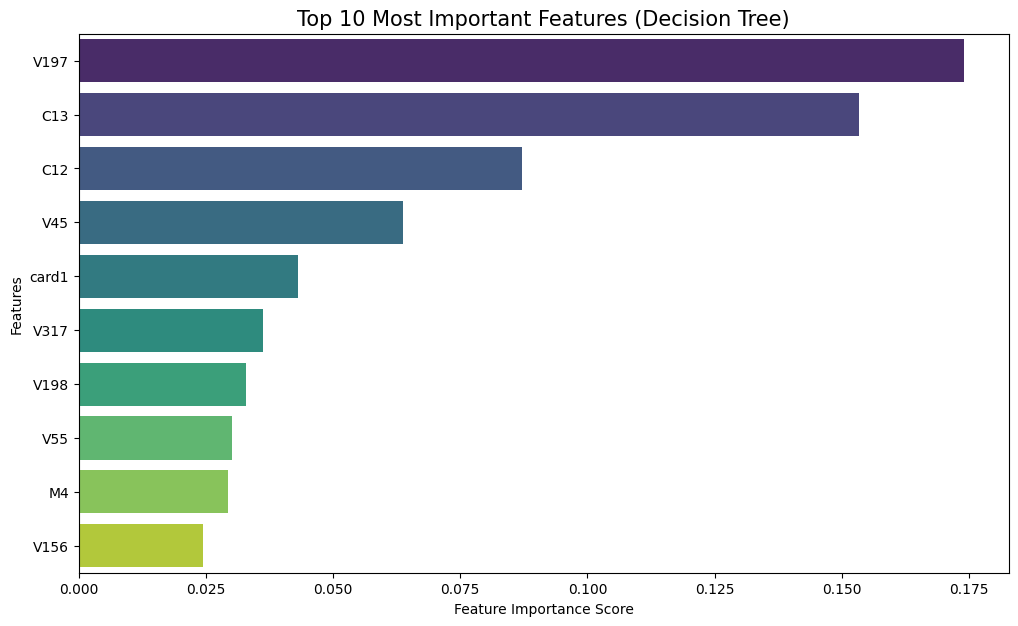

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


X_temp = pipeline_dt.named_steps['cleaner'].transform(X_train)
X_transformed = pipeline_dt.named_steps['encoder'].transform(X_temp)

features = X_transformed.columns
importances = pipeline_dt.named_steps['model'].feature_importances_

df_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=df_importance, hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Most Important Features (Decision Tree)', fontsize=15)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()

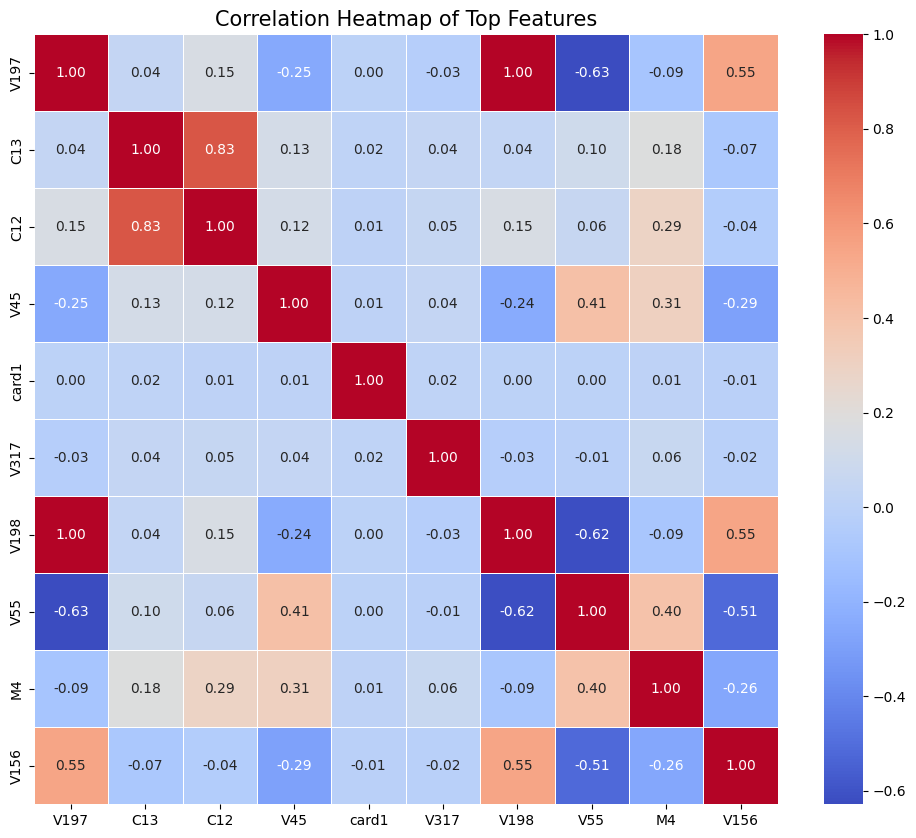

In [15]:

top_features = df_importance['Feature'].tolist()

plt.figure(figsize=(12, 10))
cor_matrix = X_transformed[top_features].corr()

sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Top Features', fontsize=15)
plt.show()

In [16]:
mlflow.set_experiment("Decision_Tree_Experiment")

X_pre = pipeline_dt.named_steps['encoder'].transform(
    pipeline_dt.named_steps['cleaner'].transform(X_train)
)
corr_matrix = X_pre.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] >= 0.99)]

final_dt_pipeline = Pipeline([
    ('cleaner', mpc.FraudDataCleaner(drop_threshold=0.9)),
    ('encoder', mpc.FraudEncoder()),
    ('model', DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=15,
        criterion='entropy',
        random_state=42
    ))
])

with mlflow.start_run(run_name="DT_Final_Optimized"):
    X_train_c = X_train.drop(columns=to_drop, errors='ignore')
    X_val_c = X_val.drop(columns=to_drop, errors='ignore')
    
    final_dt_pipeline.fit(X_train_c, y_train)
    
    tr_auc = roc_auc_score(y_train, final_dt_pipeline.predict_proba(X_train_c)[:, 1])
    vl_auc = roc_auc_score(y_val, final_dt_pipeline.predict_proba(X_val_c)[:, 1])
    
    mlflow.log_param("max_depth", 12)
    mlflow.log_param("min_samples_leaf", 15)
    mlflow.log_param("dropped_cols", len(to_drop))
    mlflow.log_metric("train_auc", tr_auc)
    mlflow.log_metric("val_auc", vl_auc)
    mlflow.sklearn.log_model(final_dt_pipeline, "final_dt_model")
    
    print(f"🎯 Train: {tr_auc:.4f} | Val: {vl_auc:.4f} | Gap: {tr_auc - vl_auc:.4f}")
    #Overfitting-ში წავიდა

2026/05/06 17:02:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 17:02:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🎯 Train: 0.9554 | Val: 0.7939 | Gap: 0.1615
🏃 View run DT_Final_Optimized at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5/runs/d08f8bee561d47579ab355d0ab50c114
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5


In [17]:
mlflow.set_experiment("Decision_Tree_Experiment")

final_dt_pipeline = Pipeline([
    ('cleaner', mpc.FraudDataCleaner(drop_threshold=0.9)),
    ('encoder', mpc.FraudEncoder()),
    ('model', DecisionTreeClassifier(
        max_depth=6,              
        min_samples_leaf=50,      
        max_features='sqrt',     
        random_state=42
    ))
])

with mlflow.start_run(run_name="DT_Pruned_Strict"):
    X_train_c = X_train.drop(columns=to_drop, errors='ignore')
    X_val_c = X_val.drop(columns=to_drop, errors='ignore')
    
    final_dt_pipeline.fit(X_train_c, y_train)
    
    tr_auc = roc_auc_score(y_train, final_dt_pipeline.predict_proba(X_train_c)[:, 1])
    vl_auc = roc_auc_score(y_val, final_dt_pipeline.predict_proba(X_val_c)[:, 1])
    
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("min_samples_leaf", 50)
    mlflow.log_metric("train_auc", tr_auc)
    mlflow.log_metric("val_auc", vl_auc)
    
    print(f"🎯 Train: {tr_auc:.4f} | Val: {vl_auc:.4f} | Gap: {tr_auc - vl_auc:.4f}")

🎯 Train: 0.8291 | Val: 0.7819 | Gap: 0.0472
🏃 View run DT_Pruned_Strict at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5/runs/e1b95b8024954841999959a5a69b5e7f
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5


In [18]:
mlflow.set_experiment("Decision_Tree_Experiment")

final_dt_pipeline = Pipeline([
    ('cleaner', mpc.FraudDataCleaner(drop_threshold=0.9)),
    ('encoder', mpc.FraudEncoder()),
    ('model', DecisionTreeClassifier(
        max_depth=8,               
        min_samples_leaf=30,       
        max_features='sqrt',
        random_state=42
    ))
])

with mlflow.start_run(run_name="DT_Golden_Middle"):
    X_train_c = X_train.drop(columns=to_drop, errors='ignore')
    X_val_c = X_val.drop(columns=to_drop, errors='ignore')
    
    final_dt_pipeline.fit(X_train_c, y_train)
    
    tr_auc = roc_auc_score(y_train, final_dt_pipeline.predict_proba(X_train_c)[:, 1])
    vl_auc = roc_auc_score(y_val, final_dt_pipeline.predict_proba(X_val_c)[:, 1])
    
    mlflow.log_param("max_depth", 8)
    mlflow.log_param("min_samples_leaf", 30)
    mlflow.log_metric("train_auc", tr_auc)
    mlflow.log_metric("val_auc", vl_auc)
    
    print(f"🎯 Golden Train: {tr_auc:.4f} | Val: {vl_auc:.4f} | Gap: {tr_auc - vl_auc:.4f}")

🎯 Golden Train: 0.8404 | Val: 0.7836 | Gap: 0.0569
🏃 View run DT_Golden_Middle at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5/runs/08e4d7727e194ad8bfa590a40aaccfb7
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/5
